In [1]:
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, auc, precision_recall_curve, confusion_matrix
from sklearn.model_selection import train_test_split
from keras import layers, models, metrics


In [2]:
data_directory = Path(__name__).resolve().parent.parent / 'data'
model_dir = Path(__name__).resolve().parent.parent / 'models'
train_data = pd.read_csv(data_directory / 'train_data.csv')
test_data = pd.read_csv(data_directory / 'test_data.csv')

In [3]:
X_train_val = train_data.drop('Churn', axis=1)
y_train_val = train_data['Churn']

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25)

X_test = test_data.drop('Churn', axis=1)
y_test = test_data['Churn']

In [4]:
print(X_train.nunique())
print(X_train.info())

TotalCharges                               3764
MonthlyCharges                             1348
tenure                                       73
SeniorCitizen                                 2
gender                                        2
Partner                                       2
Dependents                                    2
PaperlessBilling                              2
MultipleLines_No                              2
MultipleLines_Yes                             2
InternetService_Fiber optic                   2
InternetService_No                            2
OnlineSecurity_No                             2
OnlineSecurity_No internet service            2
OnlineSecurity_Yes                            2
OnlineBackup_No                               2
OnlineBackup_No internet service              2
DeviceProtection_No                           2
DeviceProtection_No internet service          2
DeviceProtection_Yes                          2
TechSupport_No                          

Epoch 1/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - auc: 0.6543 - loss: 0.7309 - precision: 0.3469 - recall: 0.6911 - val_auc: 0.8084 - val_loss: 0.6574 - val_precision: 0.3751 - val_recall: 0.9320
Epoch 2/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.7355 - loss: 0.6242 - precision: 0.4049 - recall: 0.7388 - val_auc: 0.8253 - val_loss: 0.5992 - val_precision: 0.4215 - val_recall: 0.8980
Epoch 3/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7574 - loss: 0.6082 - precision: 0.4325 - recall: 0.7693 - val_auc: 0.8328 - val_loss: 0.5641 - val_precision: 0.4467 - val_recall: 0.8782
Epoch 4/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7741 - loss: 0.5797 - precision: 0.4486 - recall: 0.7741 - val_auc: 0.8381 - val_loss: 0.5502 - val_precision: 0.4595 - val_recall: 0.8669
Epoch 5/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.7752 - loss: 0.5807 - precision: 0.4486 - recall: 0.7693 - val_auc: 0.8418 - val_loss: 0.5379 - val_precision: 0.4690 - val_recall: 0.

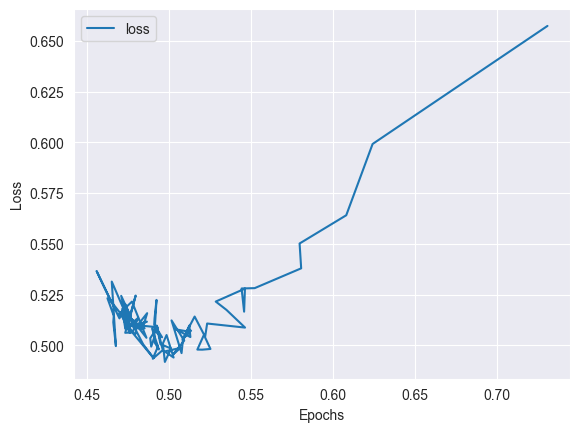

In [5]:
model = models.Sequential([
    layers.Dense(16, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(16, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),


    layers.Dense(1, activation='sigmoid')
])
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=
                                                [metrics.Precision(name='precision'),
                                                 metrics.Recall(name='recall'),
                                                 metrics.AUC(name='auc')])


history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                                             epochs=100,
                                             class_weight=class_weight)
plt.plot(history.history['loss'], history.history['val_loss'], label='loss')
# plt.plot(history.history['precision'], history.history['val_precision'], label='precision')
# plt.plot(history.history['recall'], history.history['val_recall'], label='recall')
# plt.plot(history.history['auc'], history.history['val_auc'], label='recall')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [6]:
threshold = 0.6
y_proba = model.predict(X_train)
y_pred = (y_proba > threshold).astype(int)

clf_train = classification_report(y_train, y_pred)
precision, recall, thresholds = precision_recall_curve(y_train, y_pred)
pr_auc = auc(recall, precision)
roc_score = roc_auc_score(y_train, y_pred)
print(f'Classification Report | Train Data:\n{clf_train}\nROC AUC: {roc_score: .2f}\nPR AUC: {pr_auc: .2f}')

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report | Train Data:
              precision    recall  f1-score   support

           0       0.91      0.80      0.86      2912
           1       0.59      0.79      0.68      1049

    accuracy                           0.80      3961
   macro avg       0.75      0.80      0.77      3961
weighted avg       0.83      0.80      0.81      3961

ROC AUC:  0.80
PR AUC:  0.72


In [7]:
y_proba = model.predict(X_test)
y_pred = (y_proba > threshold).astype(int)

clf_test = classification_report(y_test, y_pred)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
pr_auc = auc(recall, precision)
roc_score = roc_auc_score(y_test, y_pred)
print(f'Classification Report | Test Data:\n{clf_test}\nROC AUC: {roc_score: .2f}\nPR AUC: {pr_auc: .2f}')

56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Classification Report | Test Data:
              precision    recall  f1-score   support

           0       0.88      0.77      0.83      1294
           1       0.53      0.72      0.61       467

    accuracy                           0.76      1761
   macro avg       0.71      0.74      0.72      1761
weighted avg       0.79      0.76      0.77      1761

ROC AUC:  0.74
PR AUC:  0.66


Text(0, 0.5, 'True positive rate')

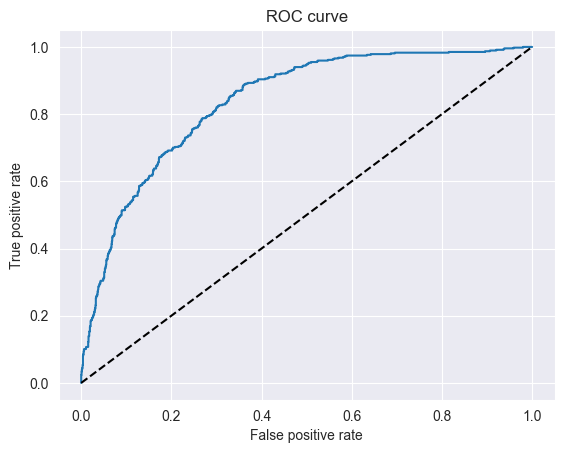

In [8]:
fpr, tpr, thr = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC curve')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')

<Axes: >

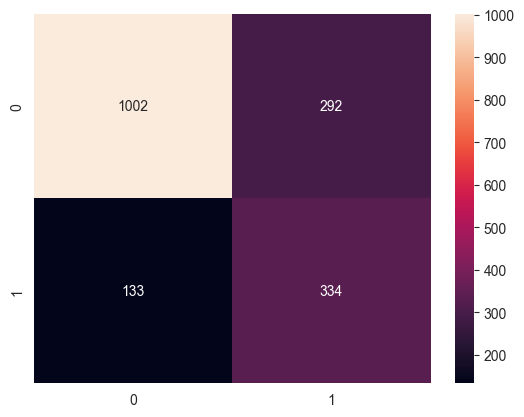

In [16]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(data=cm, annot=True, fmt='g')